## ViT

In [17]:
# 10.1 FashionMNIST 다운로드
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets

# 클래스별로 최대 max_len개씩만 뽑아 작은 서브셋을 만드는 함수
# ViT는 사전학습 모델을 파인튜닝하는 경우가 많아서, 실습에서는 데이터를 줄여 학습 시간을 단축함
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)  # {클래스 번호: [해당 클래스 샘플 인덱스들]}
    for idx, label in enumerate(dataset.train_labels):  # 최신 버전에서는 dataset.targets 권장
        target_idx[int(label)].append(idx)

    # 각 클래스에서 앞쪽 max_len개 인덱스만 잘라 하나의 리스트로 이어 붙임
    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)  # 원본 데이터셋에서 선택한 인덱스만 보는 뷰


# FashionMNIST: 28x28 흑백(1채널) 의류 이미지, 10개 클래스
# ViT 입력(보통 224x224, 3채널)과 형식이 달라서 이후 이미지 프로세서로 크기/채널 변환이 필요함
train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes            # 클래스 이름 리스트
class_to_idx = train_dataset.class_to_idx  # {클래스 이름: 정수 라벨} — 이후 ViT 분류 헤드의 id2label/label2id 구성에 사용

print(classes)
print(class_to_idx)

# 학습용: 클래스당 1000개 → 총 10,000개
subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
# 테스트용: 클래스당 100개 → 총 1,000개
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

print(f"Training Data Size : {len(subset_train_dataset)}")
print(f"Testing Data Size : {len(subset_test_dataset)}")
print(train_dataset[0])  # (PIL 이미지, 라벨) 튜플 — 아직 텐서 변환 전 상태

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training Data Size : 10000
Testing Data Size : 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x37CE10B50>, 9)


/opt/homebrew/Caskroom/miniforge/base/envs/dl-euron/lib/python3.10/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [18]:
# 10.2 이미지 전처리
import torch
from torchvision import transforms
from transformers import AutoImageProcessor

# 사전학습된 ViT의 전처리 설정(입력 크기, 정규화 평균/표준편차)을 불러옴
# vit-base-patch16-224-in21k: ViT-Base, 16x16 패치, 224x224 입력, ImageNet-21k로 사전학습
# → 224/16 = 14이므로 이미지 하나가 14x14 = 196개 패치 토큰으로 쪼개짐 (+ [CLS] 토큰 1개)
image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),  # PIL(28x28, 0~255) → 텐서 [1, 28, 28], 값 범위 0~1
        transforms.Resize(
            # ViT 사전학습 시 입력 크기(224x224)에 맞춤
            # 패치 개수와 위치 임베딩 크기가 이 해상도에 맞춰져 있어서 크기를 맞춰야 함
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            # 흑백 1채널을 3번 복제해 [3, 224, 224]로 만듦
            # ViT 패치 임베딩(Conv2d)이 RGB 3채널 입력을 기대하기 때문
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            # 사전학습 때 사용한 정규화 값과 동일하게 맞춰야 사전학습 가중치가 제대로 동작함
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

print(f"size : {image_processor.size}")        # {'height': 224, 'width': 224}
print(f"mean : {image_processor.image_mean}")  # [0.5, 0.5, 0.5]
print(f"std : {image_processor.image_std}")    # [0.5, 0.5, 0.5] → 값 범위를 -1~1로 변환

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


size : {'height': 224, 'width': 224}
mean : [0.5, 0.5, 0.5]
std : [0.5, 0.5, 0.5]


In [19]:
# 10.3 ViT 데이터로더 적용
from torch.utils.data import DataLoader

# 배치 단위로 샘플을 묶는 함수
# Hugging Face ViT 모델은 입력을 "pixel_values", 정답을 "labels"라는 키로 받으므로 딕셔너리로 반환
def collator(data, transform):
    images, labels = zip(*data)  # [(img, label), ...] → (img들), (label들)로 분리
    pixel_values = torch.stack([transform(image) for image in images])  # 각 이미지 전처리 후 [B, 3, 224, 224]로 쌓음
    labels = torch.tensor([label for label in labels])                   # [B]
    return {"pixel_values": pixel_values, "labels": labels}

train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),  # 전처리를 배치 생성 시점에 적용
    drop_last=True  # 마지막에 32개가 안 되는 배치는 버림
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

batch = next(iter(train_dataloader))
for key, value in batch.items():
    print(f"{key} : {value.shape}")
# pixel_values : torch.Size([32, 3, 224, 224])
# labels : torch.Size([32])

pixel_values : torch.Size([32, 3, 224, 224])
labels : torch.Size([32])


In [20]:
# 10.4 사전 학습된 ViT 모델
from transformers import ViTForImageClassification

# 사전학습된 ViT 인코더 위에 이미지 분류용 선형 헤드가 붙은 모델
# 구조: 패치 임베딩 → [CLS] 토큰 + 위치 임베딩 → Transformer 인코더 12층 → [CLS] 출력 → classifier
model = ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
    num_labels=len(classes),  # 분류 헤드 출력 차원을 FashionMNIST 클래스 수(10)로 설정
    id2label={idx: label for label, idx in class_to_idx.items()},  # {0: 'T-shirt/top', ...} 예측 결과를 이름으로 변환할 때 사용
    label2id=class_to_idx,                                         # {'T-shirt/top': 0, ...}
    ignore_mismatched_sizes=True  # 사전학습 헤드와 출력 크기가 달라도 에러 없이 헤드만 새로 초기화
)

# 분류 헤드: [CLS] 토큰의 768차원 출력 → 10개 클래스 로짓
# 인코더는 사전학습 가중치를 쓰고, 이 헤드는 무작위 초기화 상태라 파인튜닝으로 학습해야 함
print(model.classifier)  # Linear(in_features=768, out_features=10, bias=True)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=10, bias=True)


In [21]:
# 10.5 패치 임베딩 확인

# ViT 임베딩 모듈 구조 확인
# patch_embeddings(Conv2d, kernel=16, stride=16) + cls_token + position_embeddings + dropout
print(model.vit.embeddings)

batch = next(iter(train_dataloader))
print("image shape :", batch["pixel_values"].shape)  # [32, 3, 224, 224]

# 패치 임베딩: 16x16 패치 단위로 잘라 각 패치를 768차원 벡터로 투영
# Conv2d(3 → 768, kernel 16, stride 16) → [32, 768, 14, 14] → flatten/transpose → [32, 196, 768]
print("patch embeddings shape :",
    model.vit.embeddings.patch_embeddings(batch["pixel_values"]).shape
)  # [32, 196, 768]

# 전체 임베딩: 맨 앞에 학습 가능한 [CLS] 토큰을 붙이고 위치 임베딩을 더함
# 196개 패치 + 1개 [CLS] = 197개 토큰 → Transformer 인코더의 입력 시퀀스
# 최종 분류는 이 [CLS] 토큰의 인코더 출력으로 수행
print("[CLS] + patch embeddings shape :",
    model.vit.embeddings(batch["pixel_values"]).shape
)  # [32, 197, 768]

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
image shape : torch.Size([32, 3, 224, 224])
patch embeddings shape : torch.Size([32, 196, 768])
[CLS] + patch embeddings shape : torch.Size([32, 197, 768])


In [22]:
# 10.6 하이퍼파라미터 설정
from transformers import TrainingArguments

# Trainer가 사용할 학습 설정
# device 지정 옵션이 없어도 Trainer가 MPS를 자동 감지해서 사용함 (use_mps_device는 deprecated)
args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",  # 체크포인트 저장 경로
    save_strategy="epoch",                    # 에폭마다 체크포인트 저장
    evaluation_strategy="epoch",              # 에폭마다 검증 (최신 버전은 eval_strategy, 아래 참고)
    learning_rate=1e-5,  # 사전학습 가중치를 크게 망가뜨리지 않도록 파인튜닝은 작은 학습률 사용
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,   # 학습 종료 후 검증 성능이 가장 좋았던 체크포인트를 불러옴
    metric_for_best_model="f1",    # 최고 모델 기준 지표 (compute_metrics에서 "f1" 키를 반환해야 함)
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,   # collator가 만든 "pixel_values"를 Trainer가 지우지 않도록 필수 설정
    seed=7
)

/opt/homebrew/Caskroom/miniforge/base/envs/dl-euron/lib/python3.10/site-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [23]:
# 10.7 매크로 평균 F1 점수
import evaluate
import numpy as np

# Trainer가 검증 때마다 호출하는 평가 함수
def compute_metrics(eval_pred):
    metric = evaluate.load("f1")  # Hugging Face evaluate의 F1 지표 (scikit-learn 필요)
    predictions, labels = eval_pred  # 모델 로짓 [N, 10], 정답 라벨 [N] (Trainer가 numpy로 변환해서 넘겨줌)
    predictions = np.argmax(predictions, axis=1)  # 로짓이 가장 큰 클래스를 예측값으로 선택
    macro_f1 = metric.compute(
        # macro: 클래스별 F1을 각각 구한 뒤 단순 평균 → 모든 클래스를 동일한 비중으로 평가
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1  # {"f1": 값} 형태 → TrainingArguments의 metric_for_best_model="f1"과 키가 맞아야 함

In [24]:
# 10.8 ViT 모델 학습
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer

# 클래스별로 최대 max_len개씩 뽑아 서브셋 생성
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):  # 최신 버전에서는 dataset.targets 권장
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)

# Trainer가 학습 시작 시 호출해 모델을 새로 생성하는 함수
# model 대신 model_init을 넘기면 seed가 고정된 상태에서 모델(분류 헤드)이 초기화되어 재현성이 보장됨
def model_init(classes, class_to_idx):
    model = ViTForImageClassification.from_pretrained(
        pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
        num_labels=len(classes),  # 분류 헤드 출력 = 10
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
    )
    # MPS 버그 우회: 패치 임베딩 Conv2d 출력은 flatten/transpose를 거치므로 역전파 때 non-contiguous 기울기가 들어옴
    # PyTorch MPS의 Conv2d backward가 이를 .view()로 처리하다 RuntimeError가 나서, 기울기를 contiguous로 바꿔 전달
    def make_grad_contiguous(module, inputs, output):
        if output.requires_grad:  # 평가(no_grad) 중에는 기울기가 없으므로 학습 때만 hook 등록
            output.register_hook(lambda grad: grad.contiguous())
    model.vit.embeddings.patch_embeddings.projection.register_forward_hook(make_grad_contiguous)
    return model

# 배치를 ViT 입력 형식 {"pixel_values", "labels"}로 묶음
def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])  # [B, 3, 224, 224]
    labels = torch.tensor([label for label in labels])                   # [B]
    return {"pixel_values": pixel_values, "labels": labels}

# 검증 시 매크로 평균 F1 계산
def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)  # 로짓 → 예측 클래스
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1  # {"f1": 값}

train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)  # 10,000개
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)  # 1,000개

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            # ViT 사전학습 해상도 224x224 → 16x16 패치 196개
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)  # 흑백 1채널 → RGB 3채널
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,  # 사전학습과 동일한 정규화
            std=image_processor.image_std
        )
    ]
)

# Trainer가 MPS를 자동 감지해서 사용함 (별도 device 지정 불필요)
args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    evaluation_strategy="epoch",  # transformers 4.46+에서는 eval_strategy="epoch"
    learning_rate=1e-5,           # 파인튜닝용 작은 학습률
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,  # "pixel_values" 컬럼 유지
    seed=7
)

trainer = Trainer(
    # Trainer는 model_init의 인자가 1개면 trial(하이퍼파라미터 탐색용)을 넘김 → 여기선 None이라 x는 무시됨
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,  # 체크포인트에 전처리 설정도 함께 저장 (4.46+에서는 processing_class=image_processor)
)
trainer.train()  # 모델과 배치를 자동으로 mps로 옮겨 학습

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
/var/folders/4q/3301trc50fz6_vl0qx1b71r00000gn/T/ipykernel_47064/1475423956.py:116: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this 

  0%|          | 0/1875 [00:00<?, ?it/s]

{'loss': 1.9229, 'grad_norm': 2.5189201831817627, 'learning_rate': 9.333333333333334e-06, 'epoch': 0.2}
{'loss': 1.2681, 'grad_norm': 3.7468581199645996, 'learning_rate': 8.666666666666668e-06, 'epoch': 0.4}
{'loss': 0.9285, 'grad_norm': 1.7120189666748047, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.6}
{'loss': 0.7961, 'grad_norm': 1.948559284210205, 'learning_rate': 7.333333333333333e-06, 'epoch': 0.8}
{'loss': 0.6984, 'grad_norm': 5.8718390464782715, 'learning_rate': 6.666666666666667e-06, 'epoch': 1.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.6314688324928284, 'eval_f1': 0.8857541671389612, 'eval_runtime': 44.907, 'eval_samples_per_second': 22.268, 'eval_steps_per_second': 1.403, 'epoch': 1.0}
{'loss': 0.618, 'grad_norm': 3.178318738937378, 'learning_rate': 6e-06, 'epoch': 1.2}
{'loss': 0.5677, 'grad_norm': 2.790329694747925, 'learning_rate': 5.333333333333334e-06, 'epoch': 1.4}
{'loss': 0.5326, 'grad_norm': 2.4983296394348145, 'learning_rate': 4.666666666666667e-06, 'epoch': 1.6}
{'loss': 0.5028, 'grad_norm': 2.5714569091796875, 'learning_rate': 4.000000000000001e-06, 'epoch': 1.8}
{'loss': 0.4755, 'grad_norm': 2.9652364253997803, 'learning_rate': 3.3333333333333333e-06, 'epoch': 2.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.47313836216926575, 'eval_f1': 0.9098491883999442, 'eval_runtime': 44.9734, 'eval_samples_per_second': 22.235, 'eval_steps_per_second': 1.401, 'epoch': 2.0}
{'loss': 0.4577, 'grad_norm': 3.2551326751708984, 'learning_rate': 2.666666666666667e-06, 'epoch': 2.2}
{'loss': 0.425, 'grad_norm': 5.615731239318848, 'learning_rate': 2.0000000000000003e-06, 'epoch': 2.4}
{'loss': 0.4111, 'grad_norm': 1.9270962476730347, 'learning_rate': 1.3333333333333334e-06, 'epoch': 2.6}
{'loss': 0.415, 'grad_norm': 4.458160877227783, 'learning_rate': 6.666666666666667e-07, 'epoch': 2.8}
{'loss': 0.4163, 'grad_norm': 3.210116386413574, 'learning_rate': 0.0, 'epoch': 3.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.42635825276374817, 'eval_f1': 0.922084790604061, 'eval_runtime': 44.4963, 'eval_samples_per_second': 22.474, 'eval_steps_per_second': 1.416, 'epoch': 3.0}
{'train_runtime': 3915.3288, 'train_samples_per_second': 7.662, 'train_steps_per_second': 0.479, 'train_loss': 0.6957136576334635, 'epoch': 3.0}


TrainOutput(global_step=1875, training_loss=0.6957136576334635, metrics={'train_runtime': 3915.3288, 'train_samples_per_second': 7.662, 'train_steps_per_second': 0.479, 'total_flos': 2.32492637712384e+18, 'train_loss': 0.6957136576334635, 'epoch': 3.0})

  0%|          | 0/63 [00:00<?, ?it/s]

PredictionOutput(predictions=array([[ 3.0839381 , -0.63953257, -0.30126038, ..., -0.5761697 ,
        -0.35903516, -0.62262547],
       [ 2.0499363 , -0.70999885, -0.22429338, ..., -0.8157625 ,
        -0.8399701 , -0.95959777],
       [ 3.0002882 , -0.61190885, -0.1910922 , ..., -0.5444257 ,
        -0.3716574 , -0.60604984],
       ...,
       [-0.57894355, -0.604704  , -0.5616502 , ...,  0.59315383,
         0.40543616,  2.9880776 ],
       [-0.55910283, -0.38687074, -0.30763987, ...,  0.11780845,
        -0.29105702,  3.4056494 ],
       [-0.54153544, -0.3373349 , -0.2973563 , ..., -0.2781726 ,
        -0.13516036,  3.4142091 ]], shape=(1000, 10), dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 

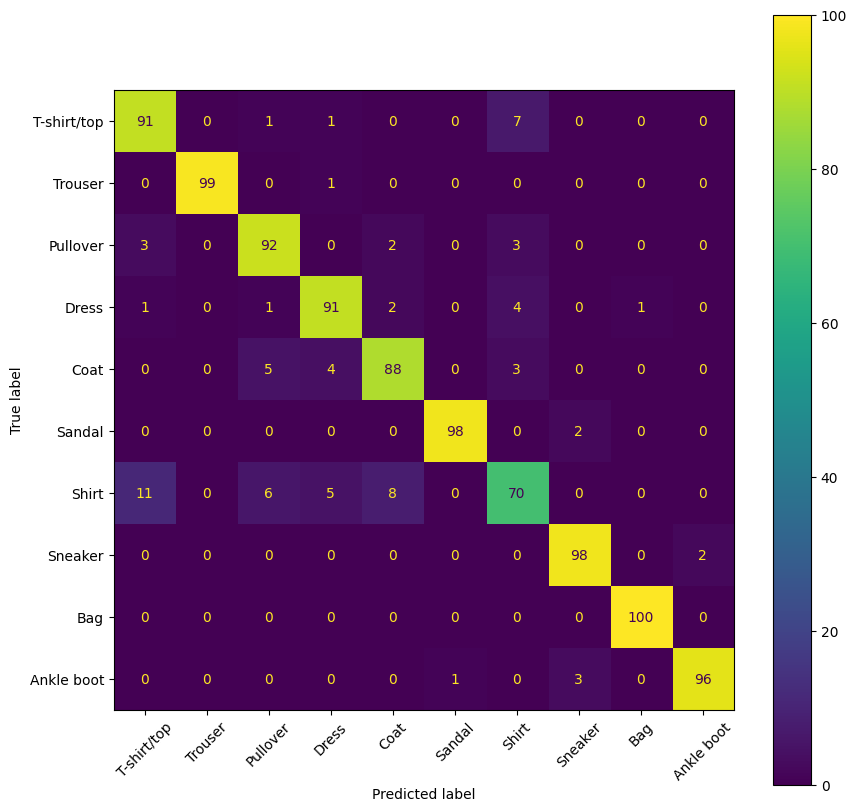

In [25]:
# 10.9 ViT 모델 성능 평가
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 학습된(최고 F1) ViT로 테스트셋 전체 예측
# Trainer가 내부적으로 mps에서 추론한 뒤 결과를 CPU numpy 배열로 모아서 반환
outputs = trainer.predict(subset_test_dataset)
print(outputs)  # PredictionOutput(predictions=로짓 [1000, 10], label_ids=정답 [1000], metrics={test_loss, test_f1, ...})

y_true = outputs.label_ids                 # 정답 라벨
y_pred = outputs.predictions.argmax(1)     # [CLS] 기반 분류 헤드 로짓 → 예측 클래스

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)  # 행: 실제 클래스, 열: 예측 클래스
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)    # 대각선 = 정답, 비대각선 = 어떤 클래스끼리 헷갈렸는지
plt.show()